In [6]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from glob import glob

from matplotlib.lines import Line2D

plt.rcParams.update({'font.size': 10})

In [9]:
def calculate_temp_variation(coefficients, model_name):

    bsplines = pd.read_csv('data/temperature_bsplines.csv')

    temp_coef = []
    for i, coefs in coefficients.iterrows():

        temp = np.linspace(10, 35, 200)
        lag1_terms = sum(bsplines[f'bs_{i}'] * coefs.loc[f'temp_bs_lag1{i}'] for i in range(1, 5))
        lag2_terms = sum(bsplines[f'bs_{i}'] * coefs.loc[f'temp_bs_lag2{i}'] for i in range(1, 5))
        lag3_terms = sum(bsplines[f'bs_{i}'] * coefs.loc[f'temp_bs_lag3{i}'] for i in range(1, 5))
        lag4_terms = sum(bsplines[f'bs_{i}'] * coefs.loc[f'temp_bs_lag4{i}'] for i in range(1, 5))
        lag5_terms = sum(bsplines[f'bs_{i}'] * coefs.loc[f'temp_bs_lag5{i}'] for i in range(1, 5))

        temp_variation = pd.DataFrame({
            'coef': lag1_terms + lag2_terms + lag3_terms + lag4_terms + lag5_terms,
            'temp': temp
        })

        temp_variation['model'] = i
        temp_coef.append(temp_variation)

    temp_coef = pd.concat(temp_coef)
    temp_coef_variation = temp_coef.groupby('model').apply(lambda x: x.set_index('temp')['coef'].diff()).reset_index().transpose()
    temp_coef_variation = temp_coef_variation.drop('model')

    quantiles = temp_coef_variation.quantile([0.025, 0.5, 0.975], axis=1).transpose().reset_index()
    quantiles['temp'] = quantiles['temp'].astype(float)

    return quantiles


/tmp/ipykernel_4203/1645728280.py:8: DtypeWarning: Columns (38) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/model_input_brazil_immunity_city_with_priorinf.csv')
/tmp/ipykernel_4203/1313478457.py:24: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  temp_coef_variation = temp_coef.groupby('model').apply(lambda x: x.set_index('temp')['coef'].diff()).reset_index().transpose()
/tmp/ipykernel_4203/1313478457.py:24: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the gr

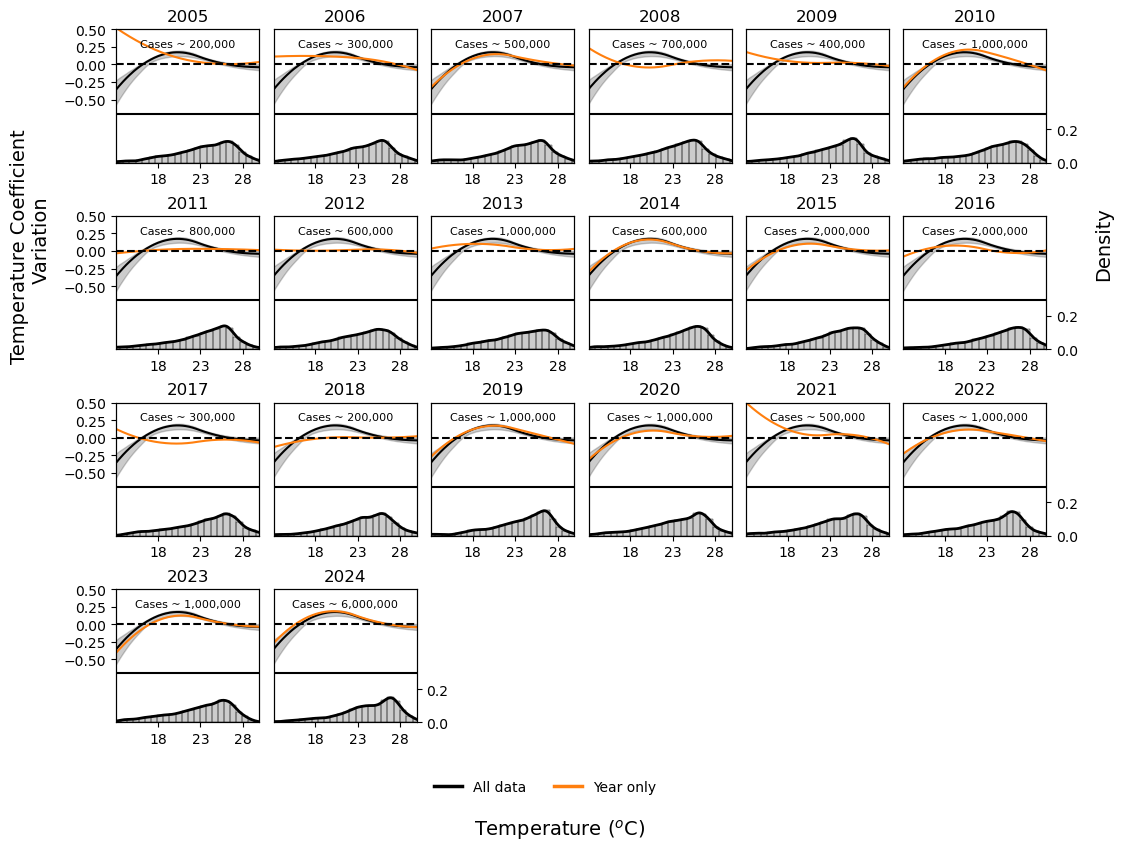

In [12]:
fig, axarr = plt.subplots(4, 6, figsize=(12, 9))
fig.subplots_adjust(hspace=0.4, wspace=0.1)

model = 'Climate(lag 1-5) + Year|region + Month|region + PriorCases + SeroRepla + Socio + Immunity'

coefficients_year = pd.read_csv('data/coefficients/coefs_by_year/all_coefs_by_year.csv')

df = pd.read_csv('data/model_input_brazil_immunity_city_with_priorinf.csv')

cases = df.groupby('year')['n_cases'].sum()

for i, (year, ax) in enumerate(zip(np.arange(2005,2025), axarr.flatten())):

    coefficients_model = pd.read_csv(f'data/coefficients/{model}_coef_state_blockboot1000.csv')
    quantiles_model = calculate_temp_variation(coefficients_model, year)

    quantiles_model.plot(x='temp', y=0.5, ax=ax, color='k', legend=False)
    ax.fill_between(
        quantiles_model['temp'],
        quantiles_model[0.025],
        quantiles_model[0.975],
        color='k', alpha=0.2
    )

    coefs = coefficients_year[coefficients_year['year'] == year].transpose().iloc[:, 0]
    temp = np.linspace(10, 35, 200)

    bsplines = pd.read_csv('data/temperature_bsplines.csv')
    lag1_terms = sum(bsplines[f'bs_{i}'] * coefs.loc[f'temp_bs_lag1{i}'] for i in range(1, 5))
    lag2_terms = sum(bsplines[f'bs_{i}'] * coefs.loc[f'temp_bs_lag2{i}'] for i in range(1, 5))
    lag3_terms = sum(bsplines[f'bs_{i}'] * coefs.loc[f'temp_bs_lag3{i}'] for i in range(1, 5))
    lag4_terms = sum(bsplines[f'bs_{i}'] * coefs.loc[f'temp_bs_lag4{i}'] for i in range(1, 5))
    lag5_terms = sum(bsplines[f'bs_{i}'] * coefs.loc[f'temp_bs_lag5{i}'] for i in range(1, 5))

    temp_variation = pd.DataFrame({
        'coef': lag1_terms + lag2_terms + lag3_terms + lag4_terms + lag5_terms,
        'temp': temp
    }).set_index('temp').diff().reset_index()

    temp_variation.plot(x='temp', y='coef', ax=ax, color='C1', legend=False)

    axt = ax.twinx()
    df_year = df[df['year'] == year]
    sns.histplot(df_year['mean_2m_air_temp_degree1'], bins=30, color='k', alpha=0.2, ax=axt, stat='density', zorder=0)
    sns.kdeplot(df_year['mean_2m_air_temp_degree1'], color='k', lw=2, ax=axt)
    
    # Set x-axis limits to match the region's temperature range
    ax.axhline(0, color='k', ls='--')
    ax.axhline(-0.7, color='k', ls='-')
    ax.set_ylim([-1.4, 0.5])
    ax.set_yticks([-0.5, -0.25, 0.0, 0.25, 0.5])
    axt.set_ylim(0, 0.8)
    axt.set_ylabel('')
    ax.set_xlabel('')
    ax.set_xticks([13, 18, 23, 28])
    ax.set_xlim(13.085, 29.958)
    
    ax.set_title(year)
    _c = cases.get(year, 0)
    _approx = round(_c / 1_000_000) * 1_000_000 if _c >= 1_000_000 else round(_c / 100_000) * 100_000
    ax.text(0.5, 0.85, f'Cases ~ {_approx:,}', transform=ax.transAxes, ha='center', va='bottom', fontsize=8)
    
    if i not in [5, 11, 17, 19]:
        axt.set_yticklabels([])
        axt.set_yticks([])
    else:
        axt.set_yticks([0.0, 0.2])

    if i not in [0, 6, 12, 18]:
        ax.set_yticklabels([])
        ax.set_yticks([])

for i in range(2,6):
    fig.delaxes(axarr[-1, i])

from matplotlib.lines import Line2D
from matplotlib.patches import Patch

legend_elements = []

legend_elements.append(Line2D([0], [0], color='k', lw=2.5, label='All data'))
legend_elements.append(Line2D([0], [0], color='C1', lw=2.5, label='Year only'))

# Place legend on the figure level or first axis
fig.legend(handles=legend_elements, frameon=False, ncol=4, bbox_to_anchor=(0.585, 0.06))

axarr[0, 0].text(-0.6, -0.6, 'Temperature Coefficient \n Variation', transform=axarr[0, 0].transAxes, va='center', ha='center', rotation=90, fontsize=14)
axarr[0, -1].text(1.4, -0.6, 'Density', transform=axarr[0, -1].transAxes, va='center', ha='center', rotation=90, fontsize=14)
axarr[2, 2].text(-0.2, -2.2, r'Temperature ($^o$C)', transform=axarr[2, 3].transAxes, va='center', ha='center', fontsize=14)

plt.savefig('img/figure_S14.png', bbox_inches='tight')